In [97]:
import os

BASE_DIR = "ABSOLUTE_PATH_TO_THE_ROOT"
DATA_DIR = os.path.join(BASE_DIR, "data")
CODE_DIR = os.path.join(BASE_DIR, "code")
FC_DIR = os.path.join(BASE_DIR, "models_save/fc")
UC_DIR = os.path.join(BASE_DIR, "models_save/uc")

import sys

sys.path.append(CODE_DIR)

In [98]:
from typing import Sequence, Tuple

import re
import math
import pickle

import numpy as np
from scipy.stats import wasserstein_distance

from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.axes import Axes

from loader.generator import DataGenerator
from config import TSDataConfig, TaskConfig
from main_utils import _init_fc
from omegaconf import DictConfig

from models.forcast.darts import SimpleDartsModel
from models.forcast.forcast_service import ForcastService
from models.forcast.forcast_base import FCPredictionData
from models.uncertainty.uc_service import UncertaintyService
from models.uncertainty.dist_match.tree import DistMatchQRF, DistMatchTree, Node
from models.uncertainty.dist_match.utils import match_ks_stat
from utils.calc_torch import calc_residuals

In [99]:
def matcher(x1, x2):
    return match_ks_stat(x1, x2) <= 0.1

In [9]:
# tree_path = "/data5/users/enver/projects/conformal/dist_bench/models_save/uc/qrf_ks_windWind_Hackberry_Generation_2019_2020.pkl"
# tree_path = "/data/enver/projects/dist_bench/models_save/uc/qrf_kl_solarSolar_Atl_data_aligned.pkl"
tree_path = "/data8/enver/projects/conformal/dist_bench/models_save/uc/qrf_ks_stat_error_normal_electricelectricity-normalized_darts-forest|100.pkl"
qrf = DistMatchQRF(
    alpha=0.1,
    n_quantile_bins=10,
    feature_dim=-1,
    matcher=matcher,
    match_mask=None,
    n_trees=10,
    bagging_ratio=0.9,
    verbose=False,
)
qrf.load_trees(tree_path)

In [101]:
def filter_right_nodes(nodes: Sequence[Node]):
    return (node for node in nodes if not node.parent.right is node)


def compute_gammas_within(
    tree: DistMatchTree, mode: str = "max", right_only: bool = False
):
    node_agg_gammas = []
    nodes = filter_right_nodes(tree.leaf_nodes) if right_only else tree.leaf_nodes

    for node in tqdm(nodes):
        xs, *_ = node.get_values()
        xs = xs[..., 0]
        n_vals = len(xs)
        gammas = np.zeros((n_vals, n_vals))
        for i in range(n_vals):
            for j in range(i, n_vals):
                gammas[i, j] = gammas[j, i] = match_ks_stat(xs[i], xs[j])

        node_agg_gammas.append(getattr(gammas, mode)(axis=-1))

    return node_agg_gammas


def compute_gammas_with_parent(
    tree: DistMatchTree, mode: str = "max", right_only: bool = False
):
    node_agg_gammas = []
    nodes = filter_right_nodes(tree.leaf_nodes) if right_only else tree.leaf_nodes

    for node in tqdm(nodes):
        xs, *_ = node.get_values()
        xs = xs[..., 0]

        split_val, dim, _ = node.parent.get_split_value()
        features = tree._take_feature_dim(split_val, dim)

        gammas = np.array([match_ks_stat(x, features) for x in xs])

        node_agg_gammas.append(getattr(gammas, mode)(axis=-1))

    return node_agg_gammas


def get_parent_ids(node: Node):
    node = node.parent
    ids = []
    while node is not None:
        ids.append(node.get_split_value()[2])
        node = node.parent
    return ids

In [102]:
def compute_dataset_epsilon0(tree: DistMatchTree):
    xs = np.concatenate([node.get_values()[0] for node in tree.leaf_nodes])
    ids = np.concatenate([node.get_values()[2] for node in tree.leaf_nodes])
    _, ids = np.unique(ids, return_index=True)
    xs = xs[ids]

    n_vals = len(xs)
    gammas = np.zeros((n_vals, n_vals))
    for i in tqdm(range(n_vals)):
        for j in range(i, n_vals):
            gammas[i, j] = gammas[j, i] = match_ks_stat(xs[i], xs[j])
    return gammas.max()

In [103]:
def compute_kappa(gamma: float, epsilon0: int, depth: int) -> float:
    kappa = 1 / math.pow(math.e, math.log(gamma / epsilon0) / depth)
    return kappa, 2 * gamma / epsilon0

In [104]:
def compute_gammas_with_shifts(tree: DistMatchTree):
    node_agg_gammas = []
    nodes = tree.leaf_nodes

    for node in nodes:
        xs, ys, ids = node.get_values()
        xs = xs[..., 0]
        ys = ys[..., None]
        shifted_xs = np.concatenate([xs, ys], axis=-1)[:, 1:]

        for x, shifted_x in zip(xs, shifted_xs):
            node_agg_gammas.append(match_ks_stat(x, shifted_x))

    return node_agg_gammas

In [105]:
def compute_gammas_within_wo_parent(tree: DistMatchTree, right_only: bool = False):
    node_distances = []
    nodes = filter_right_nodes(tree.leaf_nodes) if right_only else tree.leaf_nodes

    for node in nodes:
        xs, *_, ids = node.get_values()
        xs = xs[..., 0]
        parent_ids = get_parent_ids(node)
        xs = xs[~np.isin(ids, parent_ids)]

        n_vals = len(xs)
        distances = np.zeros((n_vals, n_vals))
        for i in range(n_vals):
            for j in range(i, n_vals):
                distances[i, j] = distances[j, i] = match_ks_stat(xs[i], xs[j])

        node_distances.append(distances)

    return node_distances


def get_node_distance_data(qrf, agg_mode="max"):
    avg_val_lens = 0
    qrf_gammas = []
    for tree in qrf.trees:
        node_distances = compute_gammas_within_wo_parent(tree)
        avg_val_lens += sum([len(node_vals) for node_vals in node_distances]) / len(
            node_distances
        )
        node_distances = [
            getattr(dists, agg_mode)(axis=-1)
            for dists in node_distances
            if len(dists) > 0
        ]
        qrf_gammas.append(np.concatenate(node_distances))

    avg_val_lens = avg_val_lens / len(qrf.trees)
    qrf_gammas = np.concatenate(qrf_gammas)
    return qrf_gammas, avg_val_lens

In [106]:
LABEL_FS = 40
TICK_FS = 35
TEXT_FS = 35

In [107]:
def plot_gamma_box_plot(ax: Axes, labels, datasets, avg_leaves, gammas, colors):
    bp = ax.boxplot(
        datasets,
        tick_labels=labels,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker="s", markerfacecolor="white", markeredgecolor="k", markersize=9
        ),
        medianprops=dict(color="k", linewidth=2.2),
        whiskerprops=dict(color="gray", linewidth=1.7),
        capprops=dict(color="gray", linewidth=1.7),
        showfliers=False,
    )

    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(mcolors.to_rgba(c, 0.44))
        patch.set_edgecolor((0, 0, 0, 1.0))

    ax.set_xticklabels(labels, fontsize=TICK_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)

    non_empty = [d for d in datasets if len(d) > 0]
    y_max_global = max(np.max(d) for d in non_empty)
    y_min_global = min(np.min(d) for d in non_empty)
    # y_max_global = max(cap.get_ydata()[0] for cap in bp['caps'][1::2])
    # y_min_global = min(cap.get_ydata()[0] for cap in bp['caps'][0::2])
    y_span = (y_max_global - y_min_global) if (y_max_global != y_min_global) else 1.0
    offset = 0.05 * y_span

    for i, (d, av, g, c) in enumerate(
        zip(datasets, avg_leaves, gammas, colors), start=1
    ):
        dmax = float(np.max(d))
        # dmax = bp["caps"][(i - 1) * 2 + 1].get_ydata()[0]

        ax.scatter(i, dmax, marker="*", s=190, color=c, zorder=5)
        if g is not None:
            ax.text(
                i,
                dmax + offset * 0.9,
                r"$\gamma =$" + f"{g:.2f}",
                ha="center",
                va="bottom",
                fontsize=TEXT_FS,
                color="black",
            )

        if av is not None:
            ax.text(
                i,
                dmax + offset * 4.5,
                r"$| \overline{\mathcal{L}} |=$" + f"{av:.2f}",
                ha="center",
                va="bottom",
                fontsize=TEXT_FS,
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0", facecolor="white", edgecolor="white", alpha=1
                ),
            )

    ax.set_xlabel("Datasets", fontsize=LABEL_FS)
    ax.set_ylabel(r"$\gamma$ Range", fontsize=LABEL_FS)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    ax.set_ylim(y_min_global - offset * 0.8, y_max_global + offset * 7.0)

    return ax

In [108]:
TREE_HOME = os.path.join(PROJECT_HOME, "models_save/uc")
TREE_THRESHOLD_PATHS = {
    "Elec.": (
        os.path.join(
            TREE_HOME,
            "qrf_ks_stat<0.1_error_normal_electricelectricity-normalized_darts-forest|{patch}.pkl",
        ),
        "electric",
        ["/some_base_dir/data/enbPI/electricity-normalized.csv"],
        0,
        "#e41a1c",
        "p",
    ),
    "Solar": (
        os.path.join(
            TREE_HOME,
            "qrf_ks_stat<0.1_error_normal_solarSolar_Atl_data_aligned_darts-forest|{patch}.pkl",
        ),
        "solar",
        ["/some_base_dir/data/enbPI/Solar_Atl_data_aligned.csv"],
        0,
        "#377eb8",
        "^",
    ),
    "Wind": (
        os.path.join(
            TREE_HOME,
            "qrf_ks_stat<0.1_error_normal_windWind_Hackberry_Generation_2019_2020_darts-forest|{patch}.pkl",
        ),
        "wind",
        ["/some_base_dir/data/enbPI/Wind_Hackberry_Generation_2019_2020.csv"],
        0,
        "#4daf4a",
        "d",
    ),
}
TREE_PATCHES = [5, 10, 25, 50, 100]

In [109]:
def plot_gamma_box_plot_from_trees(tree_paths: dict, ax: Axes, patch: int = 100):
    gamma_extractor = re.compile(r"<[0-9]+\.?[0-9]*_")
    labels = []
    data = []
    avg_leaves = []
    gammas = []
    colors = []

    for data_type, (path, *_, color, _) in tree_paths.items():
        path = path.format(patch=patch)
        qrf = load_tree(path)
        qrf_distances, avg_val_lens = get_node_distance_data(qrf, "mean")
        gamma = float(gamma_extractor.findall(path)[0][1:-1])

        labels.append(data_type)
        gammas.append(gamma)
        data.append(qrf_distances)
        avg_leaves.append(avg_val_lens)
        colors.append(color)

    return plot_gamma_box_plot(ax, labels, data, avg_leaves, gammas, colors)

In [110]:
TASK_CONFIG = DictConfig(
    {
        "task_type": "PI",
        "alpha": 0.1,
        "data_splits": [0.6, 0.15, 0.25],
        "fc_estimator_mode": "single",
        "global_norm": False,
        "add_config": None,
    }
)


def load_dataset(data_config: TSDataConfig, task_config: TaskConfig = None):
    task_config = task_config or TaskConfig(**TASK_CONFIG)
    return DataGenerator.get_data(
        data_config=data_config,
        task_config=TASK_CONFIG,
        replace_base_dir=DATA_DIR,
        X_norm_param=None,
        Y_norm_param=None,
        hydro_static_norm_param=None,
    )


def load_forecast_service(
    fc_model=None, model_config=None, data_config=None, task_config=None
):
    if fc_model is None:
        fc_model = SimpleDartsModel
        model_config = dict(
            model="darts-forest", model_params={"lags": 50, "lags_past_covariates": 50}
        )

    task_config = task_config or TASK_CONFIG

    return ForcastService(
        int_fc_model=lambda: fc_model(**model_config),
        task_config=task_config,
        model_config=model_config,
        data_config=data_config,
        persist_dir=FC_DIR,
    )

In [111]:
def get_residuals(forcast_service: ForcastService, data, is_calib: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    data = forcast_service.prepare([data], forcast_service._task_config.alpha)[0]

    if is_calib:
        calib_data = UncertaintyService._map_to_calib_data(data)
        fc_result = forcast_service.predict(
            FCPredictionData(
                ts_id=calib_data.ts_id,
                X_past=calib_data.X_pre_calib,
                Y_past=calib_data.Y_pre_calib,
                X_step=calib_data.X_calib,
                step_offset=calib_data.step_offset,
            )
        )
        return calc_residuals(Y_hat=fc_result.point, Y=calib_data.Y_calib).numpy(), fc_result.point

    fc_result = forcast_service.predict(
        FCPredictionData(
            ts_id=data.ts_id,
            X_past=data.X_calib,
            Y_past=data.Y_calib,
            X_step=data.X_test,
            step_offset=data.test_step,
        )
    )
    return calc_residuals(Y_hat=fc_result.point, Y=data.Y_test).numpy(), fc_result.point

In [112]:
def test_kernel_stability(
    residuals: np.ndarray, patch_size=100, n_samples=200, n_trials=100
):
    results = []
    choice_size = len(residuals) - patch_size
    residuals = residuals.ravel()
    patches = np.lib.stride_tricks.sliding_window_view(residuals, patch_size)

    for trial in tqdm(range(n_trials)):
        # Create two different patch distributions
        idx1 = np.random.choice(choice_size, size=n_samples)
        idx2 = np.random.choice(choice_size, size=n_samples)

        patches_P = patches[idx1]
        patches_Q = patches[idx2]

        next_P = residuals[idx1 + patch_size]
        next_Q = residuals[idx2 + patch_size]
        
        ks_per_position = []
        for pos in range(patch_size):
            ks = match_ks_stat(patches_P[:, pos], patches_Q[:, pos])
            ks_per_position.append(ks)
        
        patch_distance = np.mean(ks_per_position)
        next_distance = match_ks_stat(next_P, next_Q)

        if patch_distance > 1e-6:  # avoid division by zero
            ratio = next_distance / patch_distance
            results.append(
                {
                    "patch_dist": patch_distance,
                    "next_dist": next_distance,
                    "ratio": ratio,
                }
            )

    # Check if ratio is bounded
    ratios = np.array([r["ratio"] for r in results])
    return ratios

In [113]:
def plot_distance_ratios(ax: Axes, labels, datasets, patches, colors, markers):
    x = np.arange(len(patches))

    for label, dataset, color, marker in zip(labels, datasets, colors, markers):
        ax.plot(
            dataset,
            color=color,
            marker=marker,
            markersize=16,
            linewidth=5,
            label=label,
            zorder=3,
        )

    ax.set_xlabel("Patch", fontsize=LABEL_FS)
    ax.set_xticks(x)

    ax.set_xticklabels([f"{v}" for v in patches], fontsize=TICK_FS, rotation=0)

    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_ylabel(r"Ratio $C$", fontsize=LABEL_FS)

    ax.grid(True)
    return ax

In [114]:
def plot_distance_ratios_from_trees(tree_paths: dict, ax: Axes, patches, n_trials = 100):
    labels = []
    datasets = []
    colors = []
    markers = []

    for data_type, (qrf_path, datatype, data_paths, file_idx, color, marker) in tree_paths.items():
        data_config = DictConfig(
            {"dataset_type": datatype, "paths": data_paths, "add_config": None}
        )
        prepared = load_dataset(TSDataConfig(**data_config))[file_idx]
        forcast_service = load_forecast_service(data_config=data_config)
        residuals, _ = get_residuals(forcast_service, prepared, is_calib=True)
        ratios = np.array([
            test_kernel_stability(residuals, patch_size, n_trials=n_trials).mean()
            for patch_size in patches
        ])

        labels.append(data_type)
        datasets.append(ratios)
        colors.append(color)
        markers.append(marker)
    
    print(datasets)
    print(markers)
    
    return plot_distance_ratios(ax, labels, datasets, patches, colors, markers)

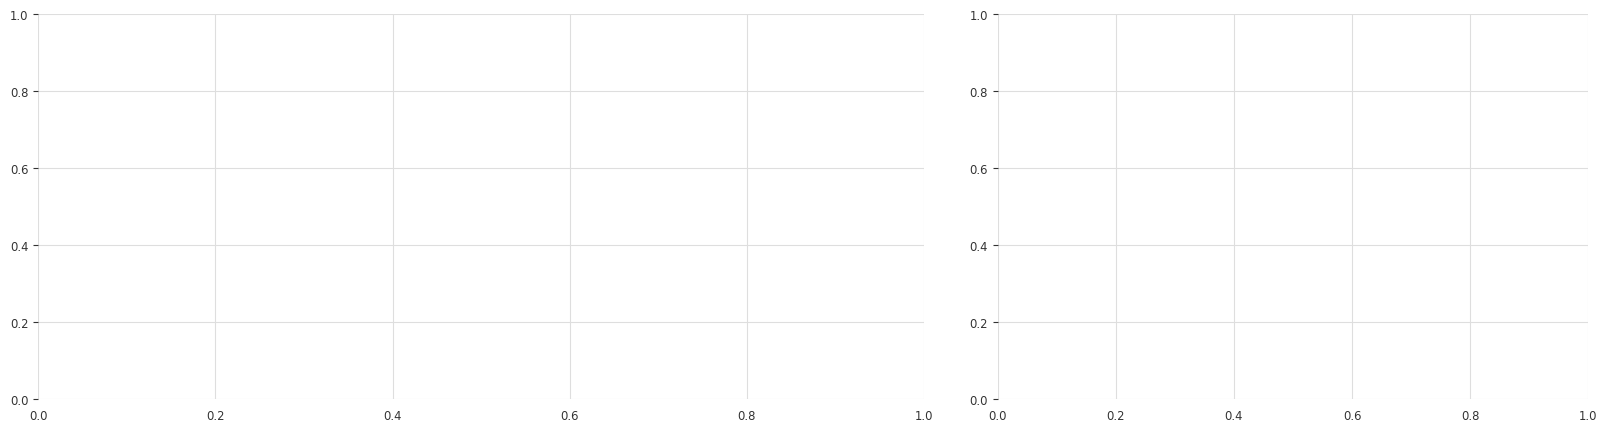

In [115]:
fig = plt.figure(figsize=(20, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 2], wspace=0.1)
ax_gammas = fig.add_subplot(gs[0, 0])
ax_ratios = fig.add_subplot(gs[0, 1])

In [116]:
ax_gammas = plot_gamma_box_plot_from_trees(TREE_THRESHOLD_PATHS, ax_gammas)

In [117]:
ax_ratios.cla()

In [118]:
np.random.seed(1)
ax_ratios = plot_distance_ratios_from_trees(TREE_THRESHOLD_PATHS, ax_ratios, TREE_PATCHES)

ax_ratios.yaxis.set_label_position("right")
ax_ratios.yaxis.tick_right()

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

[array([1.04541141, 0.99044918, 0.99508828, 1.01415032, 1.02187503]), array([1.05500497, 0.9949344 , 0.99833276, 1.01397794, 0.99607478]), array([1.0179659 , 1.01346605, 1.03560084, 1.02335071, 0.99791683])]
['p', '^', 'd']


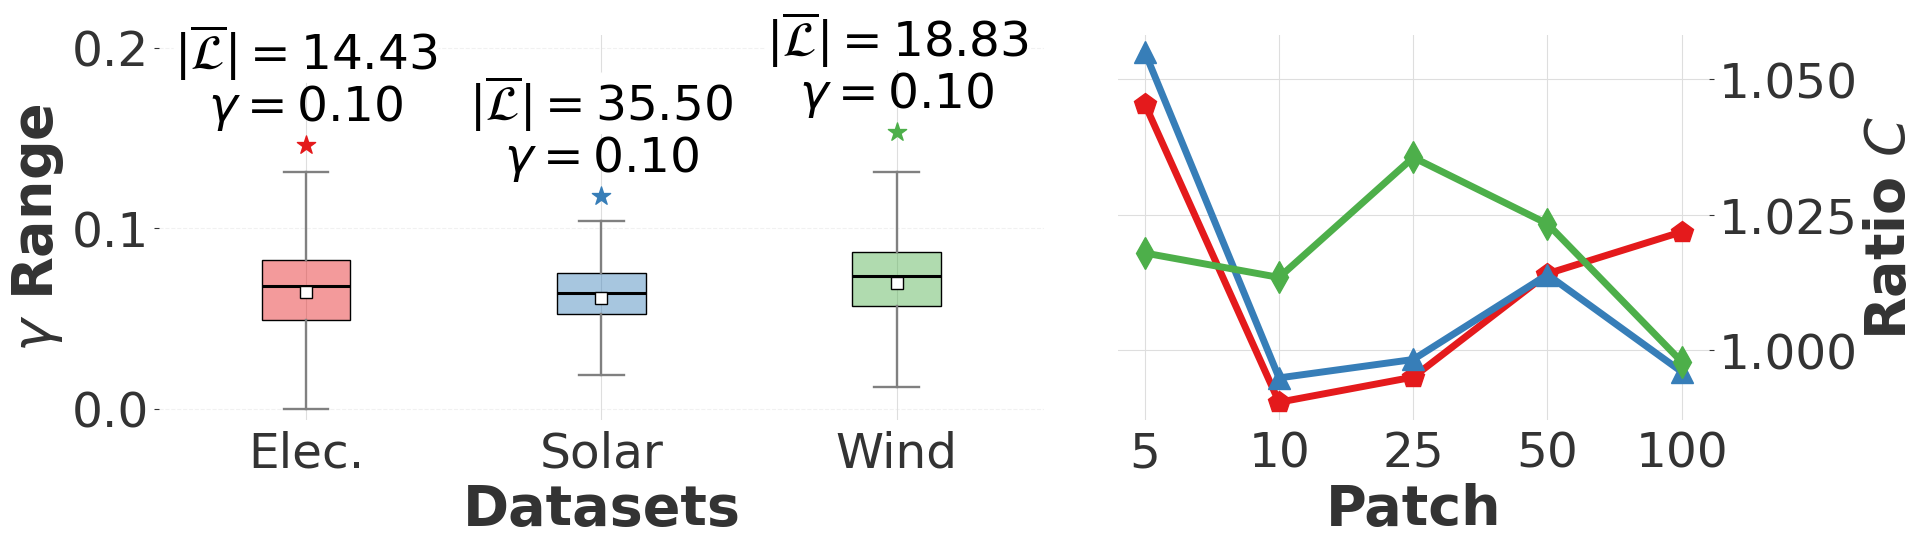

In [119]:
fig.tight_layout()
fig

In [120]:
fig.savefig("./gamma_leaf.pdf", format="pdf", bbox_inches="tight")